# Code Template for Map

1. one map per figure

## 1. one map per figure

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

In [2]:
# Function to create a colormap from a AR6 text file containing RGB values
def create_colormap_from_txt(filepath, cmap_name="custom_colormap"):
    """
    Read RGB values from a text file and create a LinearSegmentedColormap.
    RGB value shoud be 0-1 range.
    """
    rgb_data = np.loadtxt(filepath)
    colormap = mcolors.LinearSegmentedColormap.from_list(cmap_name, rgb_data)
    return colormap

In [3]:
def add_x_pattern(
    ax,
    mask,
    dx=4,
    dy=4,
    fontsize=5,
    color="#000000",
):
    """
    Draw regularly spaced X symbols
    inside a mask.
    """

    lon_mask = lon2d[mask]
    lat_mask = lat2d[mask]

    lon_grid = np.arange(
        lon_mask.min(),
        lon_mask.max(),
        dx
    )

    lat_grid = np.arange(
        lat_mask.min(),
        lat_mask.max(),
        dy
    )

    for xx in lon_grid:
        for yy in lat_grid:

            ax.text(
                xx,
                yy,
                "x",
                fontsize=fontsize,
                color=color,
                ha="center",
                va="center",
                transform=ccrs.PlateCarree(),
                zorder=3,
            )

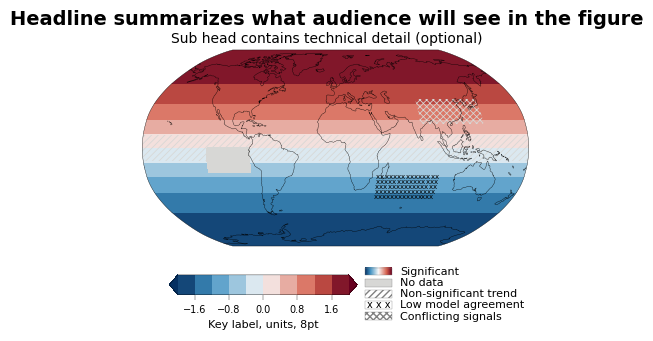

In [4]:
# ============================================================
# Dummy data
# ============================================================

lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)

lon2d, lat2d = np.meshgrid(lon, lat)

data = 2 * np.sin(np.deg2rad(lat2d))

levels = np.linspace(-2, 2, 11)

# ============================================================
# Masks
# ============================================================

# Non-significant trend
no_significance = np.abs(lat2d) < 10

# Example "conflicting signals"
conflicting_signals = (
    (lat2d > 20)
    & (lat2d < 40)
    & (lon2d > 80)
    & (lon2d < 140)
)

# Example low model agreement region
low_model_agreement = (
    (lat2d > -40)
    & (lat2d < -20)
    & (lon2d > 40)
    & (lon2d < 100)
)

# Example no-data region
no_data = (
    (lat2d > -20)
    & (lat2d < 0)
    & (lon2d > -120)
    & (lon2d < -80)
)

# ============================================================
# Figure layout
# ============================================================

fig = plt.figure(figsize=(7, 3.65))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[12, 4],
    width_ratios=[1, 1],
    hspace=0.15,
    wspace=0.02
)

# ============================================================
# Titles
# ============================================================

fig.text(
    0.5,
    0.95,
    "Headline summarizes what audience will see in the figure",
    ha="center",
    fontsize=14,
    fontweight="bold",
)

fig.text(
    0.5,
    0.90,
    "Sub head contains technical detail (optional)",
    ha="center",
    fontsize=10,
)

# ============================================================
# Line widths
# ============================================================

lw = 0.255  # 0.09 mm

# hatch line width = 0.2 mm
hatch_lw = 0.57

# ============================================================
# Map
# ============================================================

ax = fig.add_subplot(
    gs[0, :],
    projection=ccrs.Robinson()
)

ax.set_global()

ax.spines["geo"].set_linewidth(lw)

# ============================================================
# Colormap
# ============================================================

cmap = create_colormap_from_txt(
    "./continuous_colormaps_rgb_0-1/temp_div.txt"
)

# ============================================================
# Main color layer
# ============================================================

im = ax.contourf(
    lon,
    lat,
    data,
    levels=levels,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    extend="both",
    zorder=1,
)

# ============================================================
# No data
# ============================================================

ax.contourf(
    lon,
    lat,
    no_data,
    levels=[0.5, 1],
    colors=["#D7D7D5"],
    transform=ccrs.PlateCarree(),
    zorder=1.5,
)

# ============================================================
# Non-significant trend
# ============================================================

with mpl.rc_context({
    "hatch.linewidth": hatch_lw,
    "hatch.color": "#D7D7D5"
}):

    ax.contourf(
        lon,
        lat,
        no_significance,
        levels=[0.5, 1],
        hatches=["/////"],
        colors="none",
        transform=ccrs.PlateCarree(),
        zorder=2,
    )

# ============================================================
# Conflicting signals
# ============================================================

with mpl.rc_context({
    "hatch.linewidth": hatch_lw,
    "hatch.color": "#D7D7D5"
}):

    ax.contourf(
        lon,
        lat,
        conflicting_signals,
        levels=[0.5, 1],
        hatches=["xxxxx"],
        colors="none",
        transform=ccrs.PlateCarree(),
        zorder=2,
    )

# ============================================================
# Low model agreement
# ============================================================

add_x_pattern(
    ax,
    low_model_agreement,
    dx=4,
    dy=4,
    fontsize=5
)

# ============================================================
# Coastlines
# ============================================================

ax.coastlines(
    linewidth=lw,
    zorder=5,
)

# ============================================================
# COLORBAR
# ============================================================

cax = fig.add_subplot(gs[1, 0])

pos = cax.get_position()

new_pos = [
    pos.x0 + 0.15,
    pos.y0 + 0.10,
    pos.width * 0.70,
    pos.height * 0.30,
]

cax.set_position(new_pos)

cbar = plt.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
)

cbar.set_label(
    "Key label, units, 8pt",
    fontsize=8,
)

cbar.outline.set_linewidth(lw)

cbar.ax.tick_params(
    width=lw,
    labelsize=7,
)

# ============================================================
# LEGEND
# ============================================================

lax = fig.add_subplot(gs[1, 1])

lax.axis("off")

lax.set_xlim(0, 1)
lax.set_ylim(0, 1)

box_w = 0.10
box_h = 0.12

x0 = 0.10
y0 = 0.85

dy = box_h + 0.05

text_x = x0 + box_w + 0.03

# ============================================================
# Significant
# ============================================================

grad = np.linspace(0, 1, 256).reshape(1, -1)

lax.imshow(
    grad,
    extent=(x0, x0 + box_w, y0, y0 + box_h),
    cmap=cmap,
    aspect="auto",
    transform=lax.transAxes,
)

lax.add_patch(
    mpatches.Rectangle(
        (x0, y0),
        box_w,
        box_h,
        transform=lax.transAxes,
        fill=False,
        edgecolor="gray",
        linewidth=lw,
    )
)

lax.text(
    text_x,
    y0 + box_h / 2,
    "Significant",
    transform=lax.transAxes,
    va="center",
    fontsize=8,
)

# ============================================================
# Other legend entries
# ============================================================

entries = [
    (
        "No data",
        dict(
            facecolor="#D7D7D5",
            edgecolor="gray",
        ),
    ),
    (
        "Non-significant trend",
        dict(
            facecolor="white",
            edgecolor="gray",
            hatch="/////",
        ),
    ),
    (
        "Low model agreement",
        dict(
            facecolor="white",
            edgecolor="gray",
            text_hatch="x x x",
        ),
    ),
    (
        "Conflicting signals",
        dict(
            facecolor="white",
            edgecolor="gray",
            hatch="xxxxx",
        ),
    ),
]

for i, (label, style) in enumerate(entries, start=1):

    y = y0 - i * dy

    rect = mpatches.Rectangle(
        (x0, y),
        box_w,
        box_h,
        transform=lax.transAxes,
        linewidth=lw,
        facecolor=style.get("facecolor", "white"),
        edgecolor=style.get("edgecolor", "gray"),
        hatch=style.get("hatch", None),
    )

    lax.add_patch(rect)

    lax.text(
        text_x,
        y + box_h / 2,
        label,
        transform=lax.transAxes,
        va="center",
        fontsize=8,
    )

    if "text_hatch" in style:

        lax.text(
            x0 + box_w / 2,
            y + box_h / 2,
            style["text_hatch"],
            transform=lax.transAxes,
            ha="center",
            va="center",
            fontsize=7,
            color="black",
        )

# ============================================================
# Save
# ============================================================

plt.savefig(
    "./fig_svg/fig_1map.svg",
    bbox_inches="tight",
)

plt.show()
plt.close()